we might have to transpose our signal cause it does it on a  (1D column vector X). We have to import our signal as a numpy array 

In [26]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 
import dtcwt
import mne 
from scipy.stats import entropy

In [6]:
!pwd

/home/isaiah/Documents/Spring25/SP/Cognitive-Canvas-EEG/notebooks/dtcwt


Creating RawArray with float64 data, n_channels=4, n_times=762
    Range : 0 ... 761 =      0.000 ...     5.945 secs
Ready.
Using matplotlib as 2D backend.


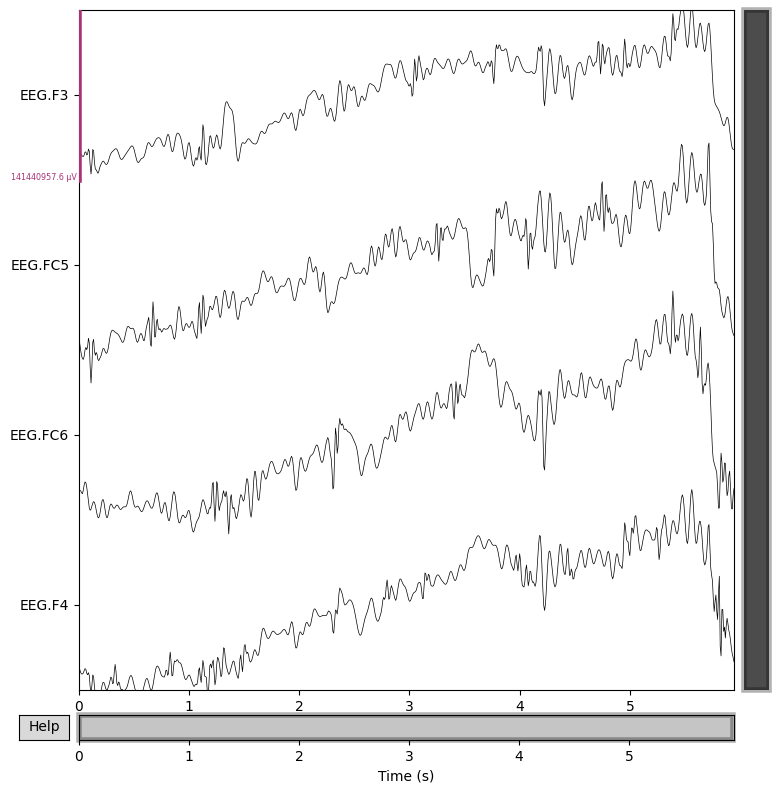

In [9]:
# import the data 

SFREQ = 128 #Hz
CH_NAMES = ['F3', 'FC5', 'FC6', 'F4']


# path = '../data/raw/raw_eeg_id_07-20250210T171013Z-001/raw_eeg_id_07/raw_eeg_allegra_left_EPOCX_268904_2025.02.10T11.11.31.05.00.md.mc.pm.fe.bp.csv'
# df = pd.read_csv(path,header = 1)
df = pd.read_csv('../../data/interim/raweeg_lzl_01_BLOCK_LEFT_EPOCX_242003_2025.03.24T16.01.16.04.00.md.csv')


# eeg_columns = [ 'EEG.AF3','EEG.F7','EEG.F3','EEG.FC5','EEG.T7','EEG.P7','EEG.O1',
                # 'EEG.O2','EEG.P8','EEG.T8', 'EEG.FC6','EEG.F4','EEG.F8','EEG.AF4']

eeg_columns = ['EEG.F3','EEG.FC5','EEG.FC6','EEG.F4']


df_eeg = df[eeg_columns]

# import into mne (https://stackoverflow.com/questions/63172453/python-read-eeg-data-form-csv-file-using-mne)
info = mne.create_info(ch_names = eeg_columns, sfreq = SFREQ, ch_types='eeg')
raw = mne.io.RawArray(df_eeg.transpose(), info)

raw.plot(scalings = "auto", proj=False, n_channels=len(raw.ch_names))
plt.show()

In [36]:
LEVELS = 4

X = raw._data[0]
transform = dtcwt.Transform1d()

coeffs = transform.forward(X, nlevels=LEVELS)

real = []
imag = []


real.append(coeffs.lowpass.real)
imag.append(coeffs.lowpass.imag)

for i in range(LEVELS):
    real.append(coeffs.highpasses[i].real)
    imag.append(coeffs.highpasses[i].imag)

print(len(real))
print(len(imag))


5
5


In [38]:
# compute the shannon entropy and variance 

def shannon_entropy(signal):
    value, counts = np.unique(signal, return_counts=True)
    probs = counts / len(signal)

    # Calculate the Shannon entropy using scipy.stats.entropy
    return entropy(probs)



vars = []
shannon_entropies = []

for i in range(LEVELS):
    vars.append(np.var(real[i]))
    vars.append(np.var(imag[i]))

    shannon_entropies.append(shannon_entropy(real[i]))
    shannon_entropies.append(shannon_entropy(imag[i])) # double check if this is being done correctly 


features = np.array(vars) * np.array(shannon_entropies)